In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

Matplotlib is building the font cache; this may take a moment.


In [5]:

df = pd.read_csv("taxi_trip_pricing.csv")
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


(None,
    Trip_Distance_km Time_of_Day Day_of_Week  Passenger_Count  \
 0             19.35     Morning     Weekday              3.0   
 1             47.59   Afternoon     Weekday              1.0   
 2             36.87     Evening     Weekend              1.0   
 3             30.33     Evening     Weekday              4.0   
 4               NaN     Evening     Weekday              3.0   
 
   Traffic_Conditions Weather  Base_Fare  Per_Km_Rate  Per_Minute_Rate  \
 0                Low   Clear       3.56         0.80             0.32   
 1               High   Clear        NaN         0.62             0.43   
 2               High   Clear       2.70         1.21             0.15   
 3                Low     NaN       3.48         0.51             0.15   
 4               High   Clear       2.93         0.63             0.32   
 
    Trip_Duration_Minutes  Trip_Price  
 0                  53.82     36.2624  
 1                  40.57         NaN  
 2                  37.27     52.90

In [6]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


Price_Category
Low       33.333333
Medium    33.333333
High      33.333333
Name: proportion, dtype: float64
Imbalance Ratio: 1.00 → Dataset is Balanced


C:\Users\User\AppData\Local\Temp\ipykernel_2512\1969616300.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Price_Category', data=df ,order=['Low','Medium','High'], palette='Set2')


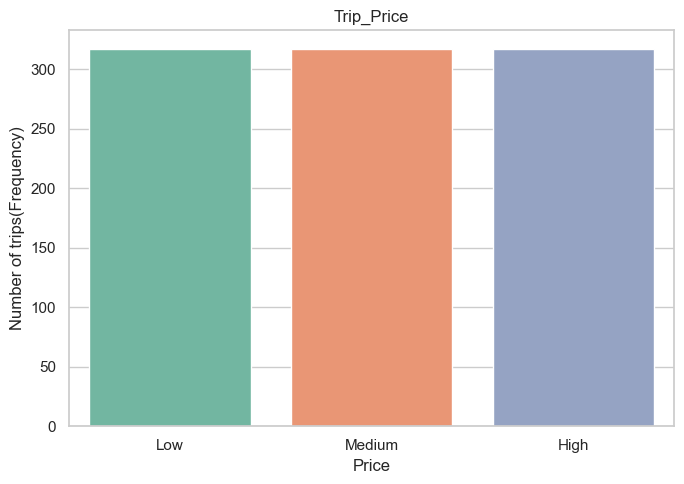

In [11]:
df['Price_Category']= pd.qcut(df['Trip_Price'],q=3,labels=['Low','Medium','High'])
print(df['Price_Category'].value_counts(normalize=True)*100)
counts= df['Price_Category'].value_counts()
imbalance_ratio= counts.max()/counts.min()

if imbalance_ratio <= 1.5:
     print(f"Imbalance Ratio: {imbalance_ratio:.2f} → Dataset is Balanced")
else:
    print(f"Imbalance Ratio: {imbalance_ratio:.2f} → Dataset is Imbalanced")

plt.figure(figsize=(7, 5))
sns.countplot(x='Price_Category', data=df ,order=['Low','Medium','High'], palette='Set2')

plt.title("Trip_Price")
plt.xlabel("Price")
plt.ylabel("Number of trips(Frequency)")
plt.tight_layout()
plt.show()

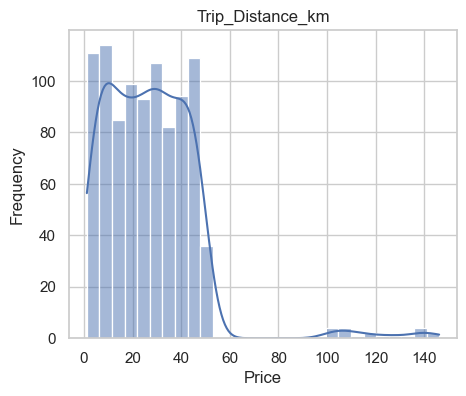

In [17]:
plt.figure(figsize=(5, 4))
sns.histplot(df['Trip_Distance_km'], kde=True)  
plt.title("Trip_Distance_km")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

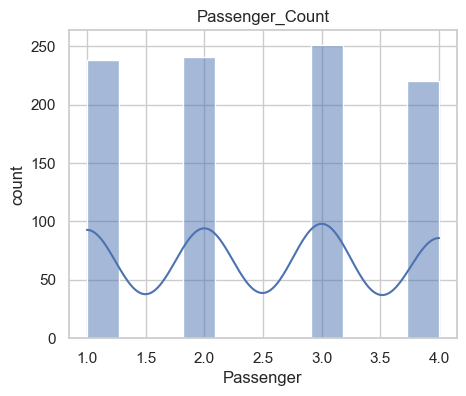

In [18]:
plt.figure(figsize=(5, 4))
sns.histplot(df['Passenger_Count'], kde=True)  
plt.title("Passenger_Count")
plt.xlabel("Passenger")
plt.ylabel("count")
plt.show()

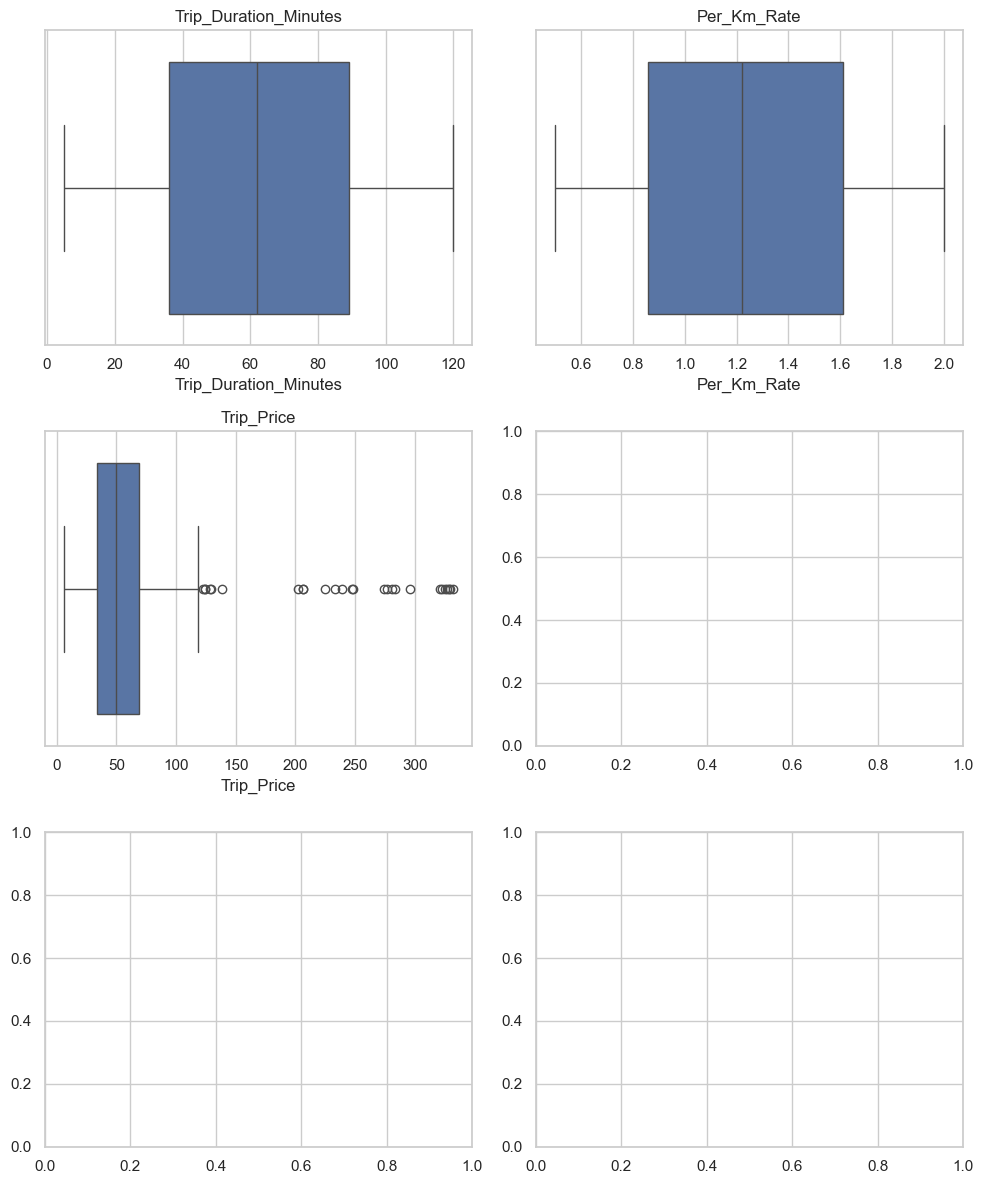

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
sns.boxplot(x=df['Trip_Duration_Minutes'], ax=axes[0, 0])
axes[0, 0].set_title('Trip_Duration_Minutes')

sns.boxplot(x=df['Per_Km_Rate'], ax=axes[0, 1])
axes[0, 1].set_title('Per_Km_Rate')

sns.boxplot(x=df['Trip_Price'], ax=axes[1, 0])
axes[1, 0].set_title('Trip_Price')

plt.tight_layout()
plt.show()


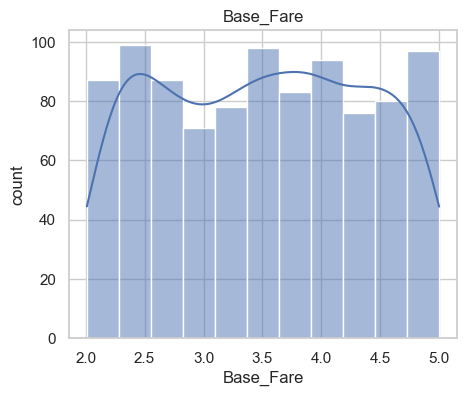

In [32]:
plt.figure(figsize=(5, 4))
sns.histplot(df['Base_Fare'], kde=True)  
plt.title("Base_Fare")
plt.xlabel("Base_Fare")
plt.ylabel("count")
plt.show()

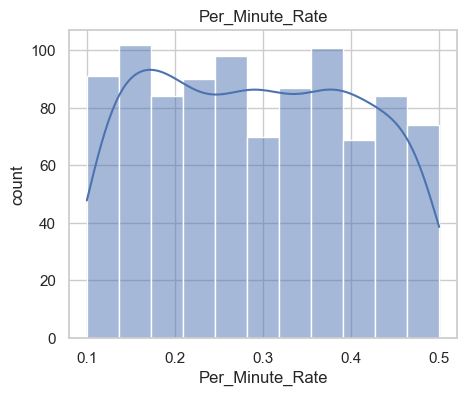

In [33]:
plt.figure(figsize=(5, 4))
sns.histplot(df['Per_Minute_Rate'], kde=True)  
plt.title("Per_Minute_Rate")
plt.xlabel("Per_Minute_Rate")
plt.ylabel("count")
plt.show()

                       Trip_Distance_km  Passenger_Count  Base_Fare  \
Trip_Distance_km               1.000000        -0.029324   0.045416   
Passenger_Count               -0.029324         1.000000   0.024339   
Base_Fare                      0.045416         0.024339   1.000000   
Per_Km_Rate                   -0.034926         0.030553   0.000713   
Per_Minute_Rate               -0.020517         0.034428  -0.018217   
Trip_Duration_Minutes         -0.036026         0.022191   0.013107   
Trip_Price                     0.722387         0.024689   0.046215   

                       Per_Km_Rate  Per_Minute_Rate  Trip_Duration_Minutes  \
Trip_Distance_km         -0.034926        -0.020517              -0.036026   
Passenger_Count           0.030553         0.034428               0.022191   
Base_Fare                 0.000713        -0.018217               0.013107   
Per_Km_Rate               1.000000         0.031853               0.027035   
Per_Minute_Rate           0.031853       

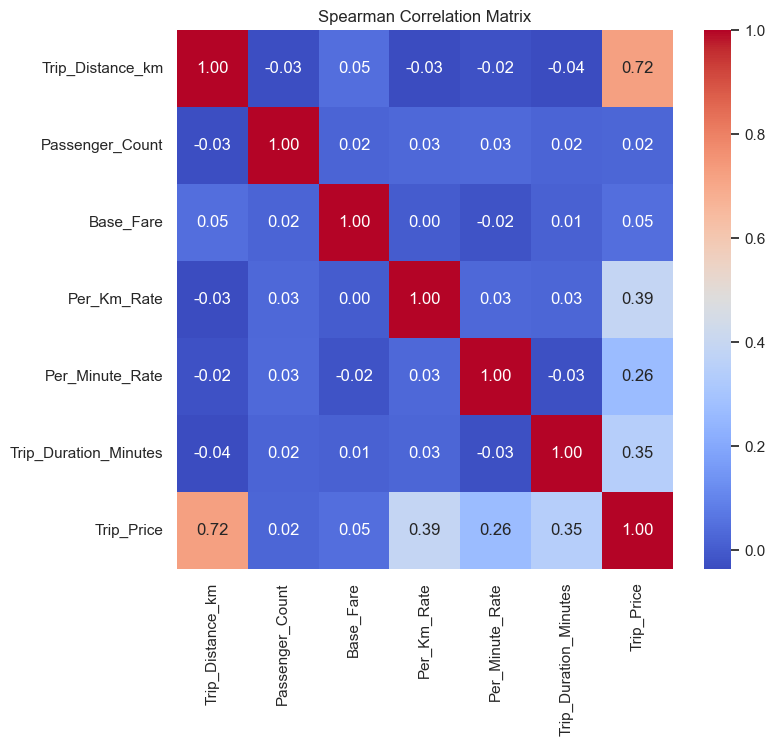

In [35]:
numeric_df = df.select_dtypes(include=['number'])
spearman_corr = numeric_df.corr(method='spearman')

# Выводим матрицу корреляции
print(spearman_corr)

# Построение тепловой карты для визуализации матрицы корреляции
plt.figure(figsize=(8, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Spearman Correlation Matrix')
plt.show()